<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Advanced-DL/blob/main/Copy_of_Exercise_7_1_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

The code block below defines a few helper functions to visualize the results. You do not need to touch them.

In [2]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The imagages are 32x32 pixels and have three color channels (red, green blue).

In [3]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


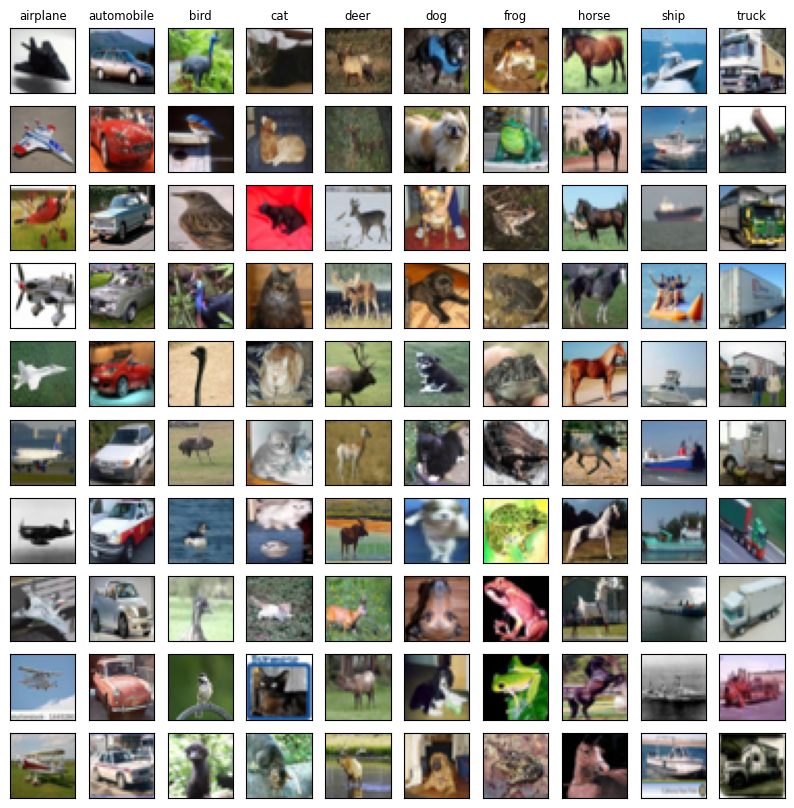

In [5]:
# Hint: To plot example images, you can use the plot examples function
plot_examples(x_train, y_train)
plt.show()

In [6]:
# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

# Hint: normalize the data
# Hint: use 20% of the test data for validation
# use 20% of test data for validation
x_valid = x_test[8000:]
y_valid = y_test[8000:]

x_test = x_test[:8000]
y_test = y_test[:8000]

# one-hot labels
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)

# normalize images to range [0,1]
x_train_norm = x_train.astype("float32") / 255.0
x_valid_norm = x_valid.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0


In [7]:
print(x_train_norm.min(), x_train_norm.max())
print(x_valid_norm.shape)
print(x_test_norm.shape)

0.0 1.0
(2000, 32, 32, 3)
(8000, 32, 32, 3)


We start with a fully connected network

In [8]:
# ----------------------------------------------------------
# Define model
# ----------------------------------------------------------
model = tf.keras.models.Sequential(
[
    layers.Flatten(input_shape=(32, 32, 3)),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(256, activation="relu"),

    layers.Dense(10, activation="softmax")
],
name="nn"
)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855,050 (3.26 MB)

 Trainable params: 855,050 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=128,
    epochs=20,
    verbose=2,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[
        tf.keras.callbacks.CSVLogger(
            "history_{}.csv".format(model.name)
        )
    ]
)

Epoch 1/20
391/391 - 9s - 24ms/step - accuracy: 0.2279 - loss: 2.0661 - val_accuracy: 0.3290 - val_loss: 1.9282
Epoch 2/20
391/391 - 9s - 23ms/step - accuracy: 0.2596 - loss: 1.9706 - val_accuracy: 0.3110 - val_loss: 1.8814
Epoch 3/20
391/391 - 8s - 21ms/step - accuracy: 0.2734 - loss: 1.9399 - val_accuracy: 0.3120 - val_loss: 1.8785
Epoch 4/20
391/391 - 7s - 18ms/step - accuracy: 0.2894 - loss: 1.9162 - val_accuracy: 0.3125 - val_loss: 1.9181
Epoch 5/20
391/391 - 9s - 22ms/step - accuracy: 0.2898 - loss: 1.9055 - val_accuracy: 0.3425 - val_loss: 1.8575
Epoch 6/20
391/391 - 8s - 20ms/step - accuracy: 0.3017 - loss: 1.8852 - val_accuracy: 0.3605 - val_loss: 1.8357
Epoch 7/20
391/391 - 8s - 20ms/step - accuracy: 0.3079 - loss: 1.8692 - val_accuracy: 0.3315 - val_loss: 1.8452
Epoch 8/20
391/391 - 8s - 21ms/step - accuracy: 0.3155 - loss: 1.8559 - val_accuracy: 0.3490 - val_loss: 1.8459
Epoch 9/20
391/391 - 8s - 20ms/step - accuracy: 0.3155 - loss: 1.8558 - val_accuracy: 0.3580 - val_loss:

In [12]:
train_loss, train_acc = model.evaluate(
    x_train_norm,
    y_train_onehot,
    verbose=0
)

valid_loss, valid_acc = model.evaluate(
    x_valid_norm,
    y_valid_onehot,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    x_test_norm,
    y_test_onehot,
    verbose=0
)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", valid_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.3787600100040436
Validation Accuracy: 0.3634999990463257
Test Accuracy: 0.3721249997615814


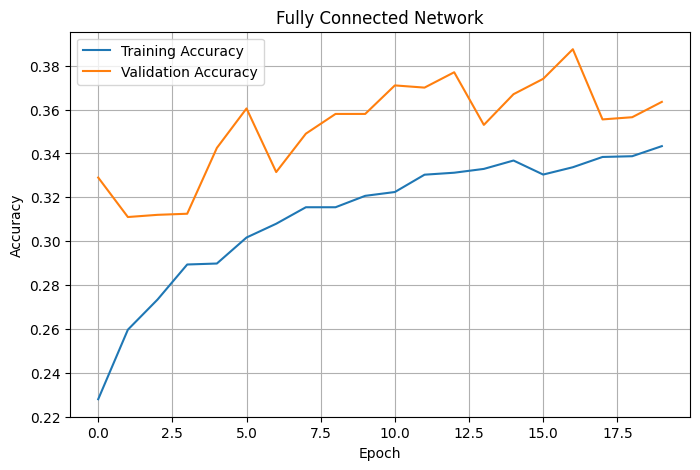

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


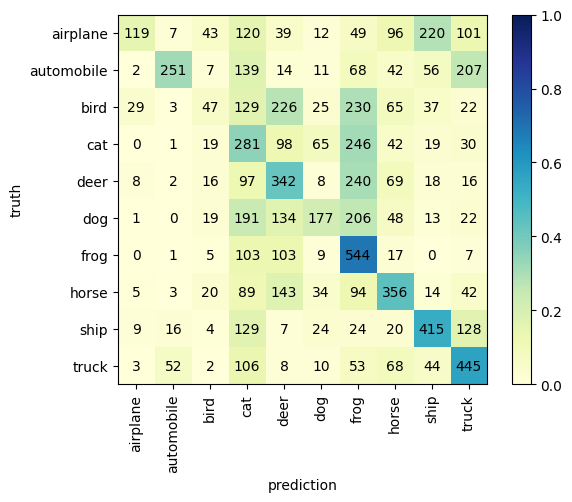

In [14]:
# ----------------------------------------------------------
# Plots
# ----------------------------------------------------------
# training curves
history = np.genfromtxt(
    "history_{}.csv".format(model.name),
    delimiter=",",
    names=True
)


# Hint: this is how you can plot the confusion matrix.
plt.figure(figsize=(8,5))

plt.plot(history["epoch"],
         history["accuracy"],
         label="Training Accuracy")

plt.plot(history["epoch"],
         history["val_accuracy"],
         label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fully Connected Network")
plt.legend()
plt.grid()

plt.show()
# calculate predictions for test set
y_predict = model.predict(
    x_test_norm,
    batch_size=128
)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)
plt.show()

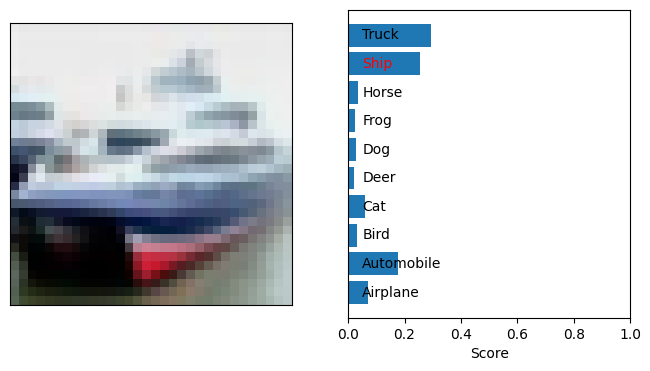

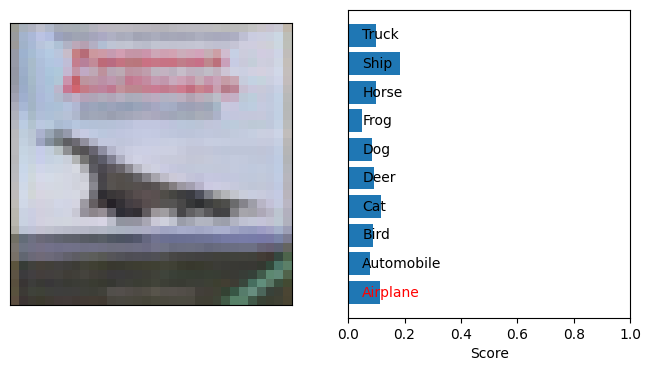

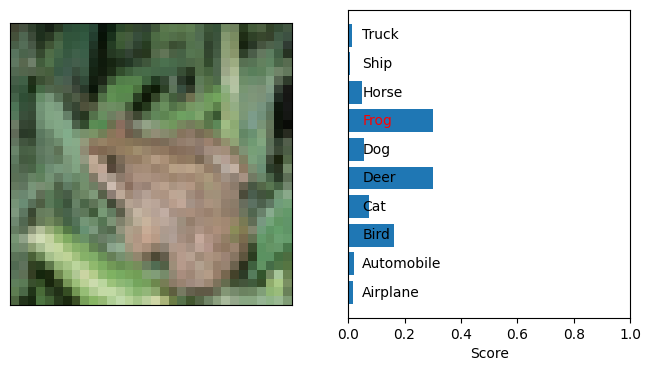

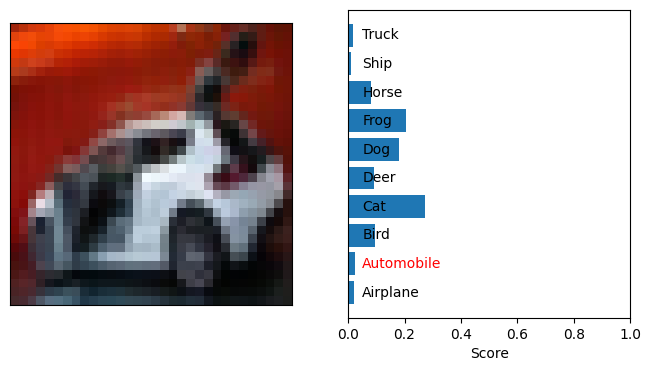

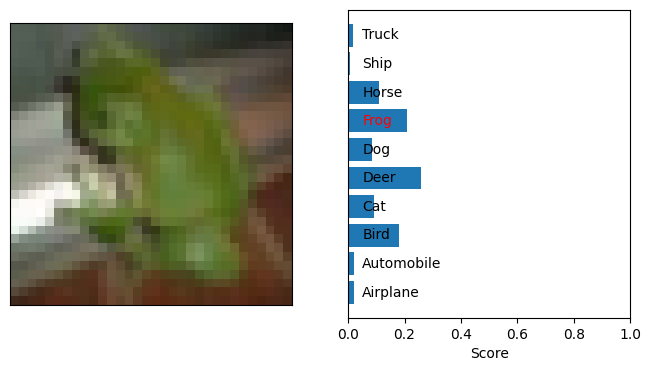

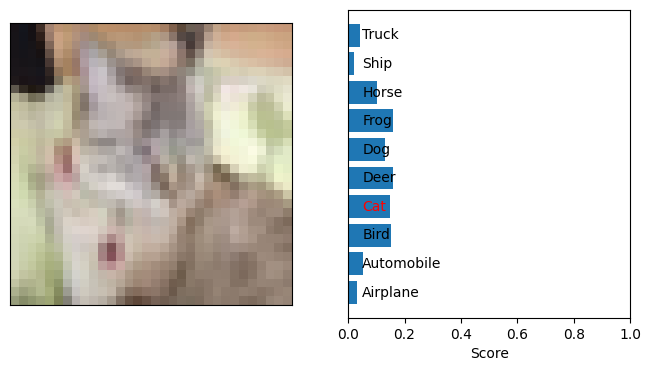

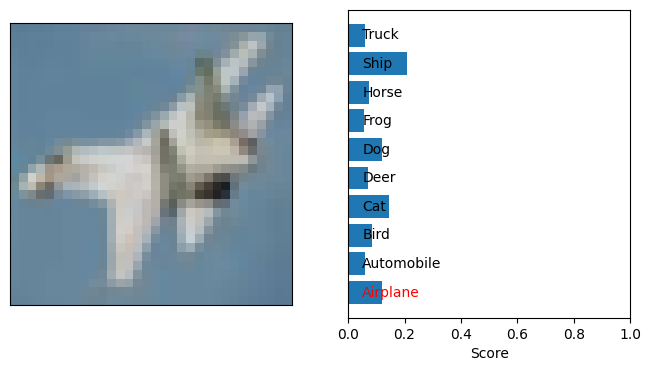

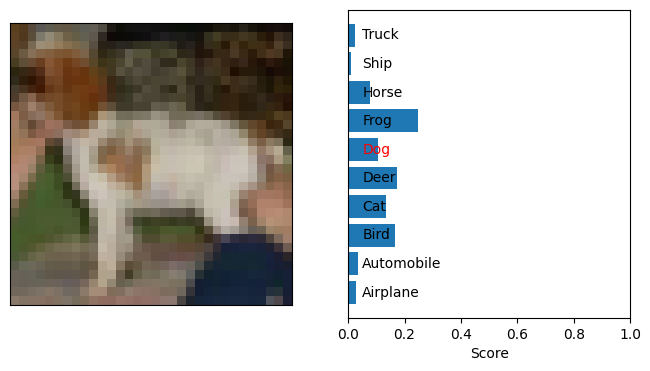

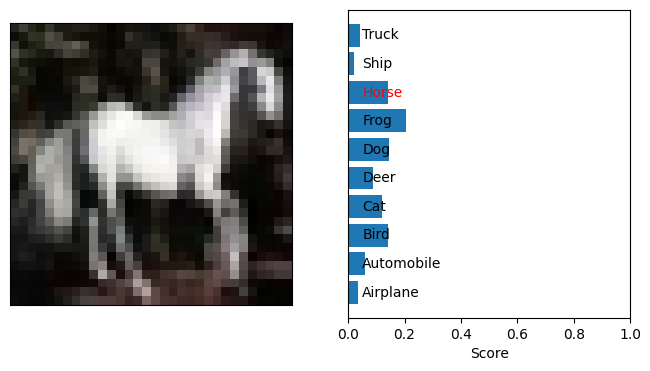

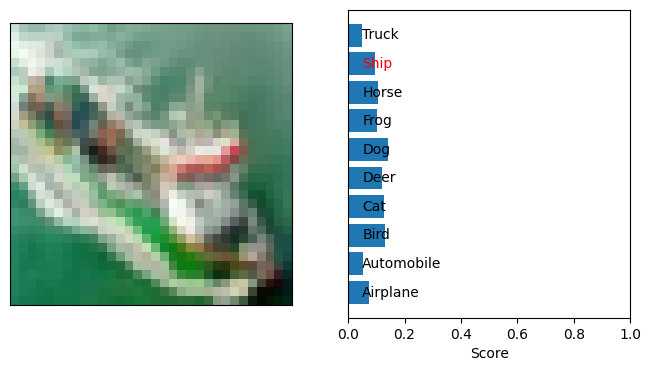

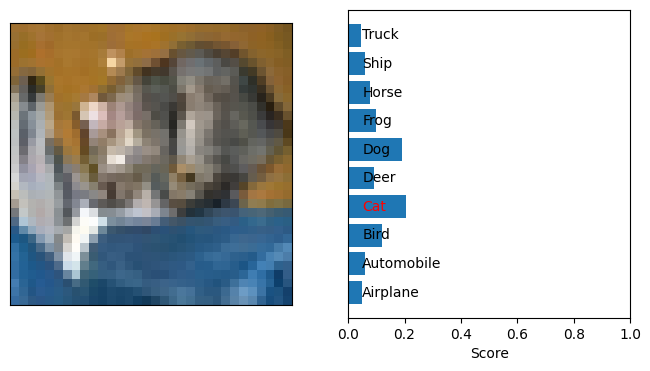

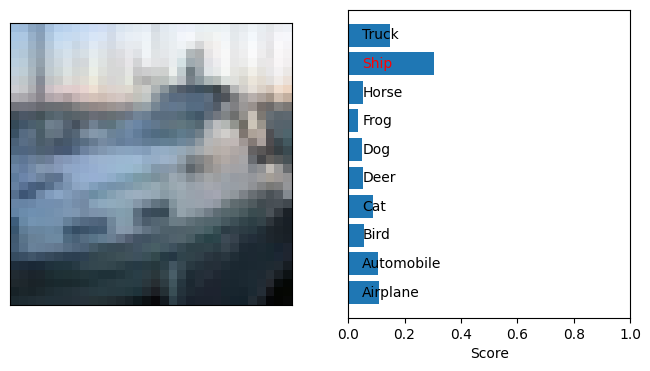

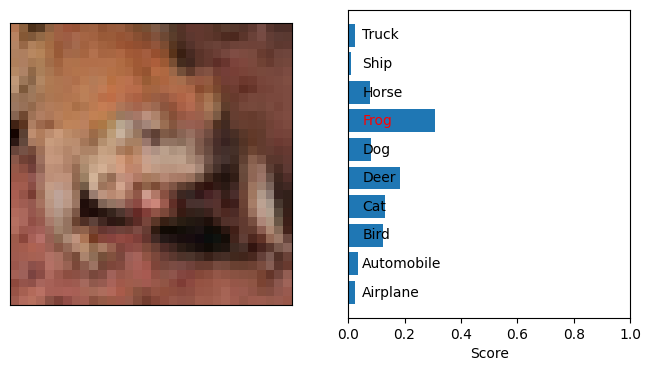

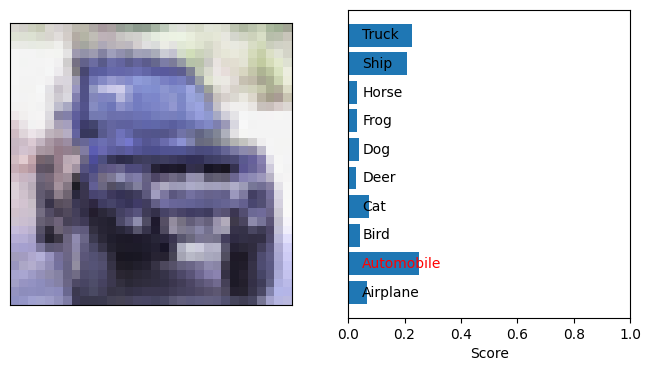

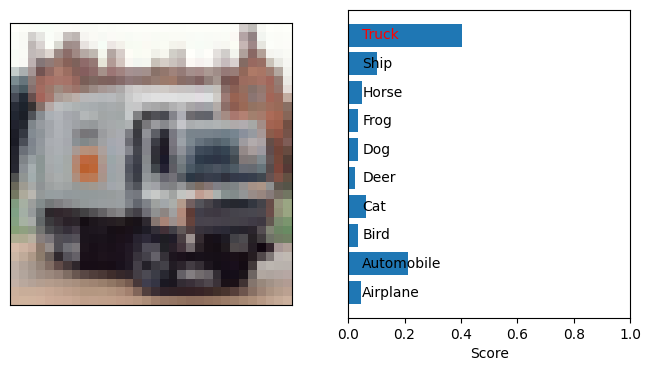

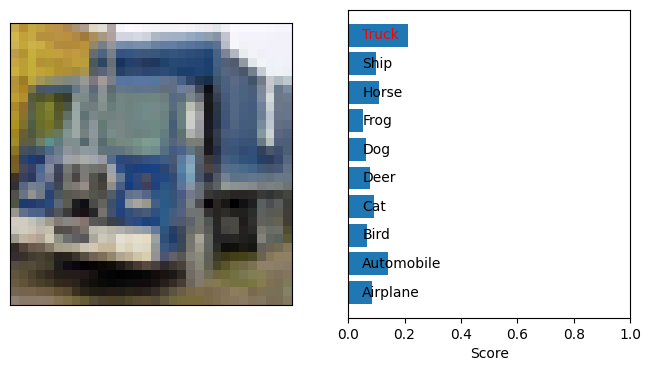

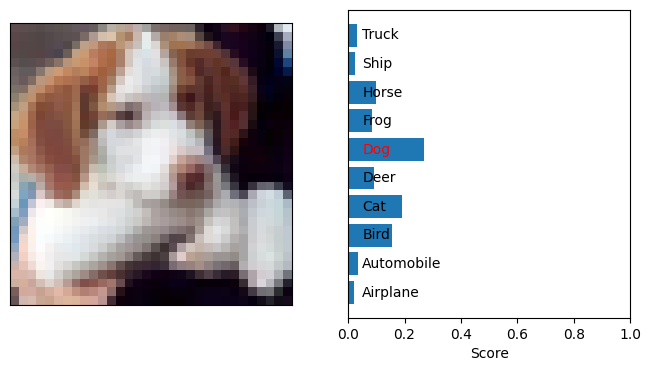

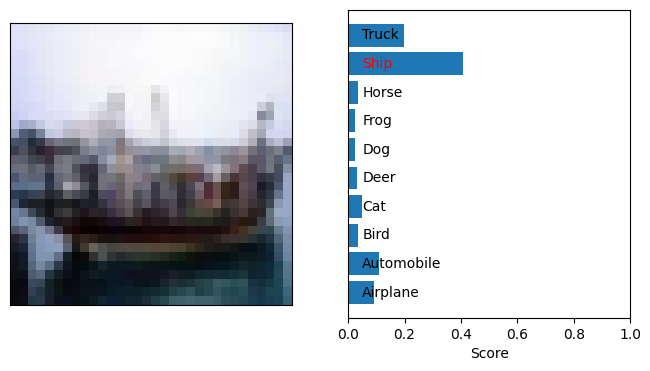

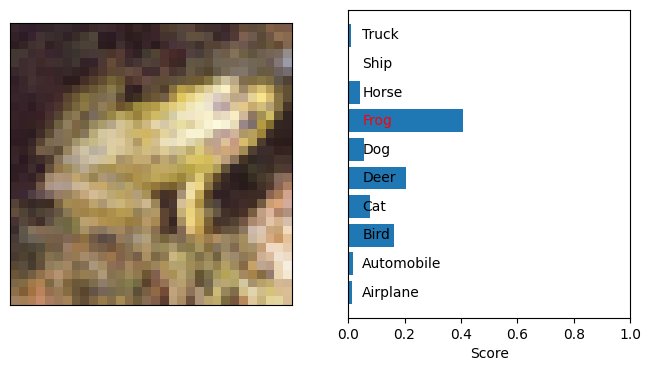

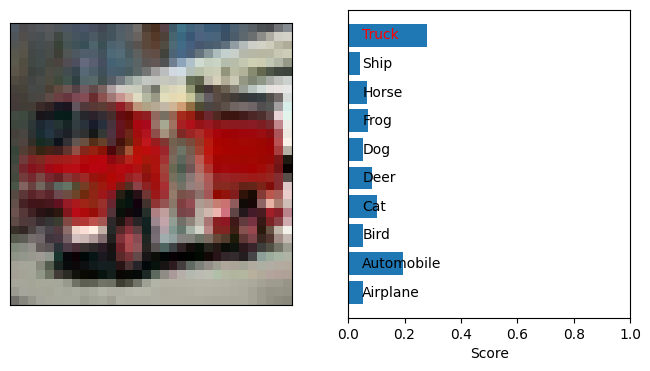

In [16]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images



# original (unnormalized) test images
x_test = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
# show first 10 incorrect predictions
for i in i0[:10]:
    plot_prediction(
        x_test[i],
        y_test_onehot[i],
        y_predict[i]
    )
    plt.show()

    # show first 10 correct predictions
for i in i1[:10]:
    plot_prediction(
        x_test[i],
        y_test_onehot[i],
        y_predict[i]
    )
    plt.show()

**CNN**
In the second part of this exercise, classify the images with a CNN.


In [17]:
# Hint: this code snipped shows how to define convolution and maxpooling layers. For more information see
# https://keras.io/api/layers/convolution_layers/convolution2d/
# https://keras.io/api/layers/pooling_layers/max_pooling2d/
model = tf.keras.models.Sequential(
[
    layers.Conv2D(
        16,
        kernel_size=(3,3),
        padding="same",
        activation="relu",
        input_shape=(32,32,3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        32,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
],
name="cnn"
)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,578 (99.91 KB)

 Trainable params: 25,578 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=128,
    epochs=40,
    verbose=2,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[
        tf.keras.callbacks.CSVLogger(
            "history_{}.csv".format(model.name)
        )
    ]
)

Epoch 1/40
391/391 - 46s - 117ms/step - accuracy: 0.3797 - loss: 1.7206 - val_accuracy: 0.4800 - val_loss: 1.4533
Epoch 2/40
391/391 - 46s - 117ms/step - accuracy: 0.4977 - loss: 1.4118 - val_accuracy: 0.5275 - val_loss: 1.3224
Epoch 3/40
391/391 - 81s - 208ms/step - accuracy: 0.5346 - loss: 1.3139 - val_accuracy: 0.5485 - val_loss: 1.2529
Epoch 4/40
391/391 - 78s - 200ms/step - accuracy: 0.5580 - loss: 1.2535 - val_accuracy: 0.5830 - val_loss: 1.1867
Epoch 5/40
391/391 - 42s - 108ms/step - accuracy: 0.5775 - loss: 1.2055 - val_accuracy: 0.5740 - val_loss: 1.1841
Epoch 6/40
391/391 - 42s - 108ms/step - accuracy: 0.5900 - loss: 1.1665 - val_accuracy: 0.6035 - val_loss: 1.1187
Epoch 7/40
391/391 - 42s - 108ms/step - accuracy: 0.6036 - loss: 1.1317 - val_accuracy: 0.6045 - val_loss: 1.0948
Epoch 8/40
391/391 - 78s - 199ms/step - accuracy: 0.6147 - loss: 1.1041 - val_accuracy: 0.6220 - val_loss: 1.0612
Epoch 9/40
391/391 - 38s - 98ms/step - accuracy: 0.6202 - loss: 1.0854 - val_accuracy: 0

In [19]:
train_loss, train_acc = model.evaluate(
    x_train_norm,
    y_train_onehot,
    verbose=0
)

valid_loss, valid_acc = model.evaluate(
    x_valid_norm,
    y_valid_onehot,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    x_test_norm,
    y_test_onehot,
    verbose=0
)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", valid_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.7559800148010254
Validation Accuracy: 0.6930000185966492
Test Accuracy: 0.7172499895095825


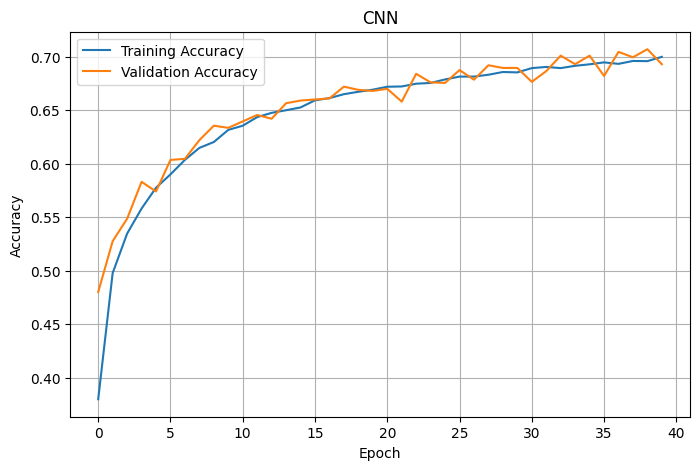

In [20]:
history = np.genfromtxt(
    "history_{}.csv".format(model.name),
    delimiter=",",
    names=True
)

plt.figure(figsize=(8,5))

plt.plot(history["epoch"],
         history["accuracy"],
         label="Training Accuracy")

plt.plot(history["epoch"],
         history["val_accuracy"],
         label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN")
plt.legend()
plt.grid()

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


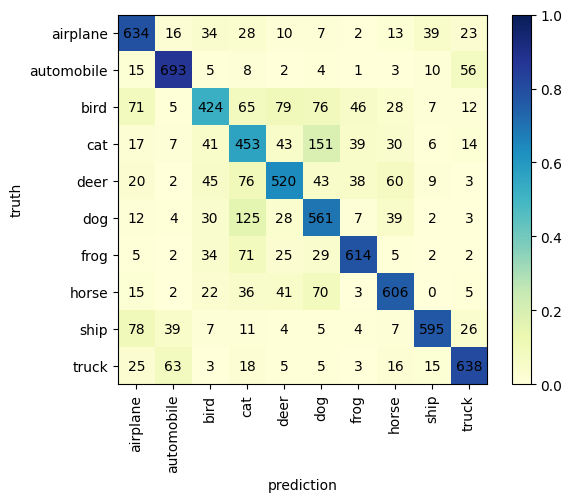

In [21]:
y_predict = model.predict(
    x_test_norm,
    batch_size=128
)

y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

plot_confusion(y_test_cl, y_predict_cl)
plt.show()

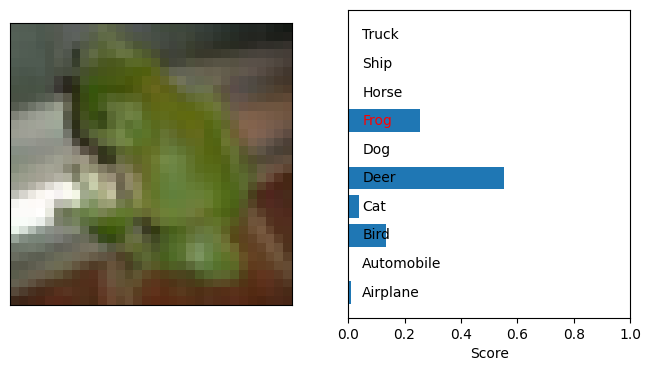

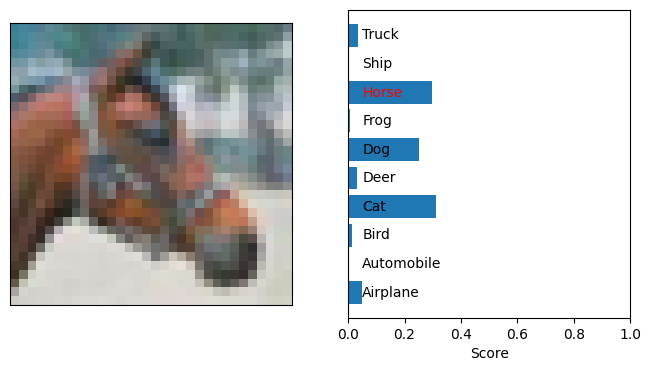

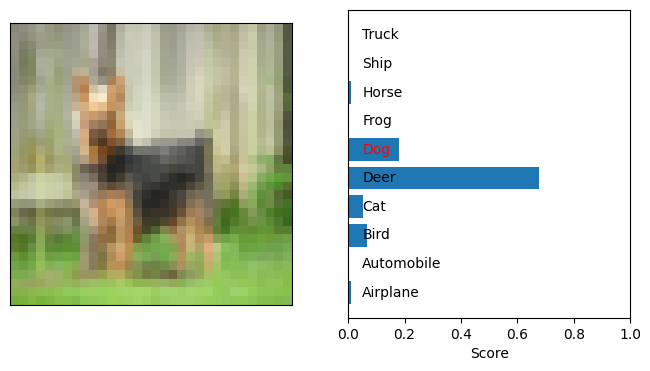

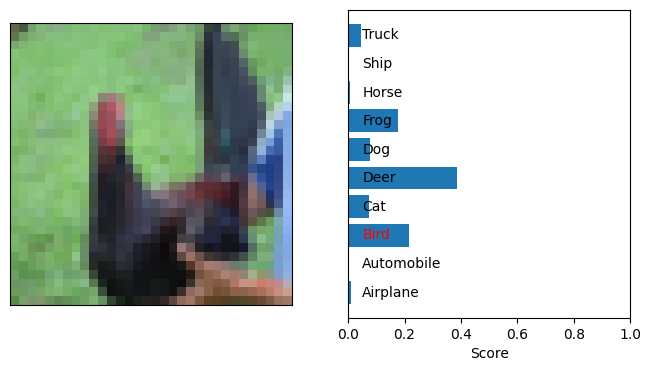

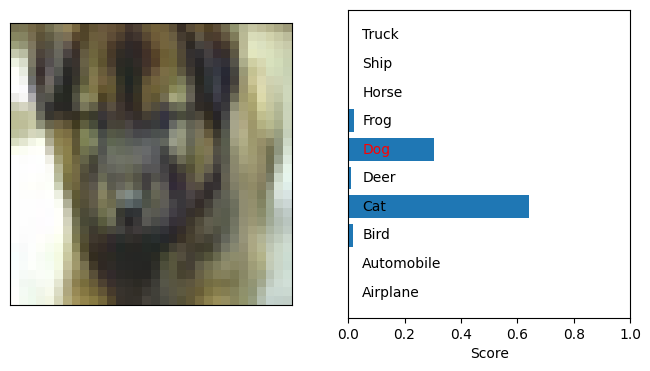

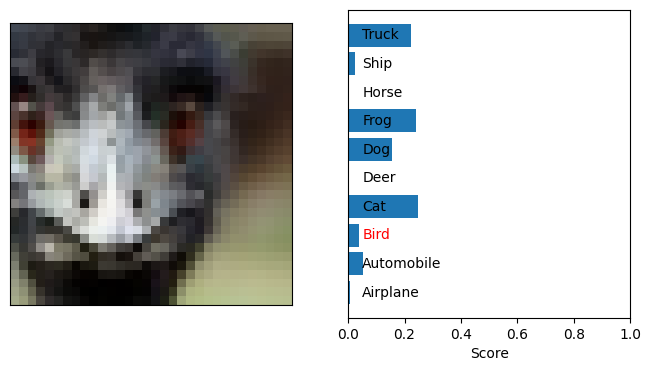

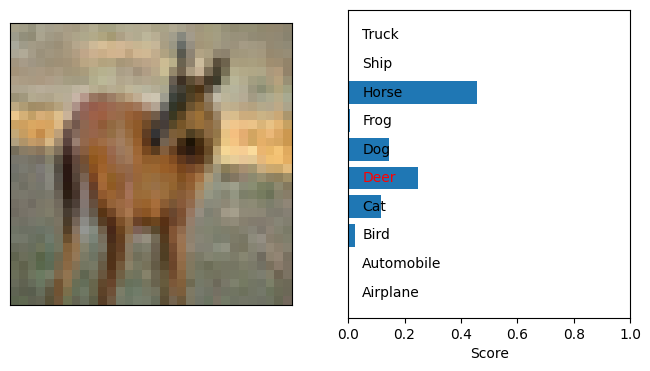

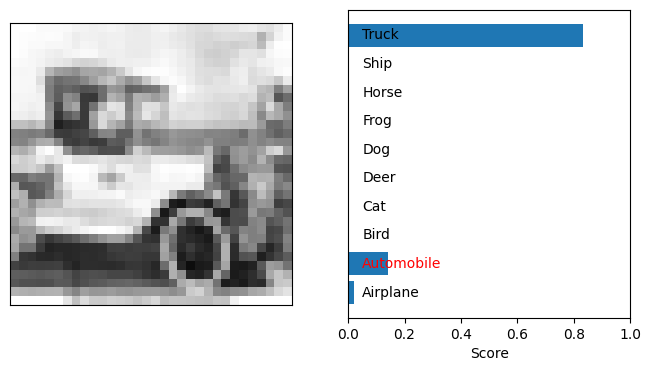

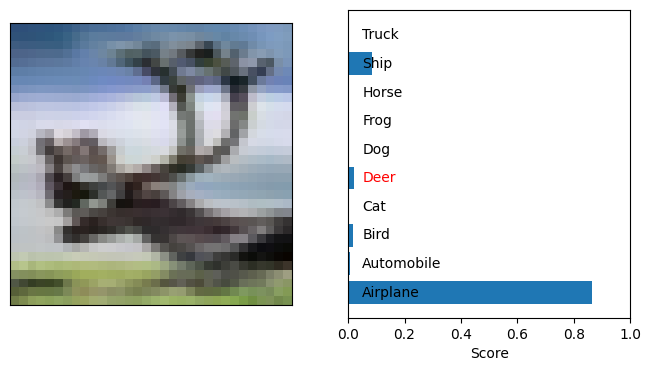

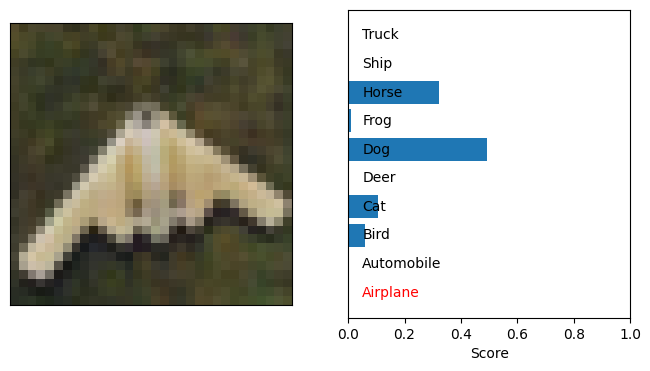

In [22]:
m = y_predict_cl == y_test_cl

i0 = np.arange(8000)[~m]

for i in i0[:10]:
    plot_prediction(
        x_test[i],
        y_test_onehot[i],
        y_predict[i]
    )
    plt.show()

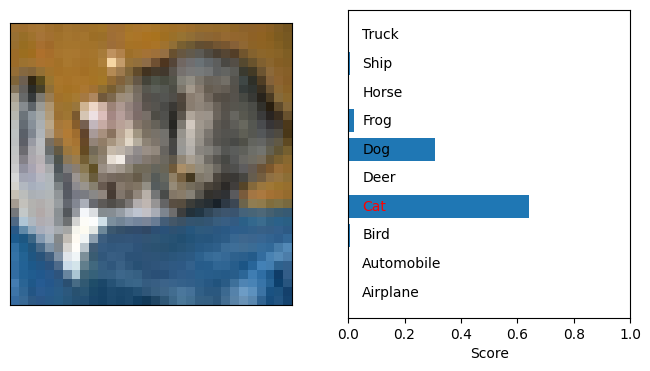

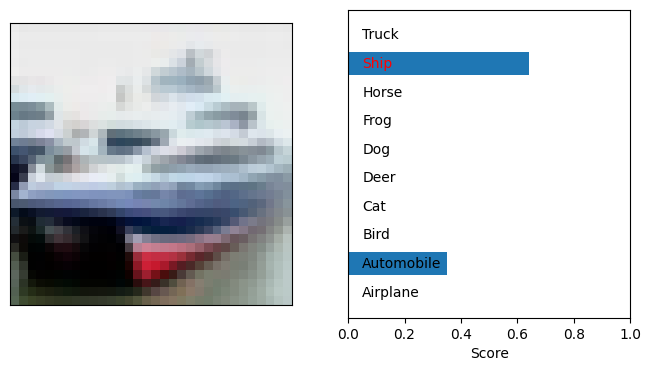

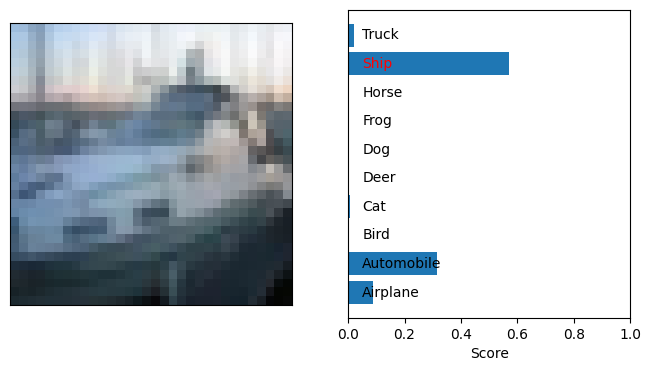

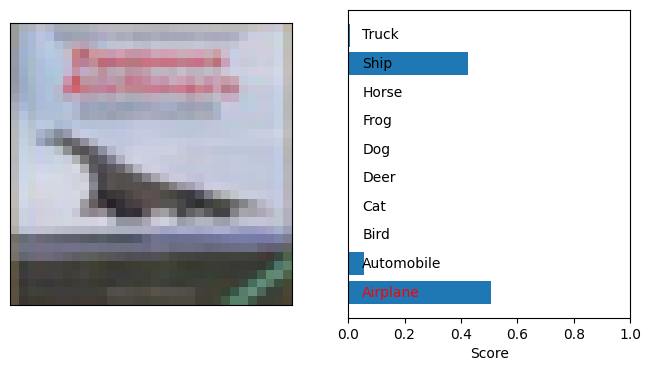

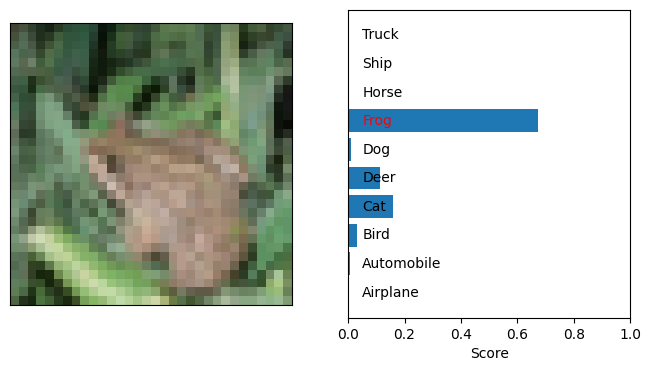

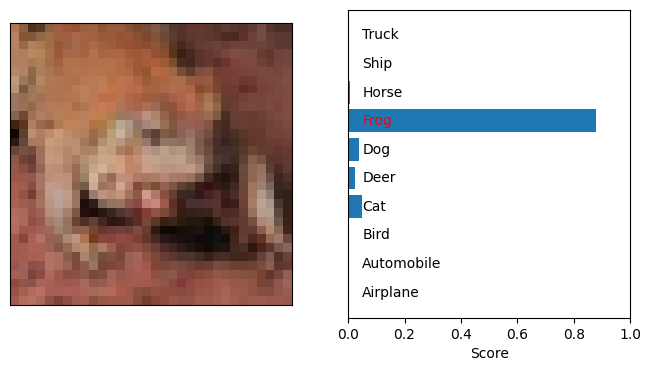

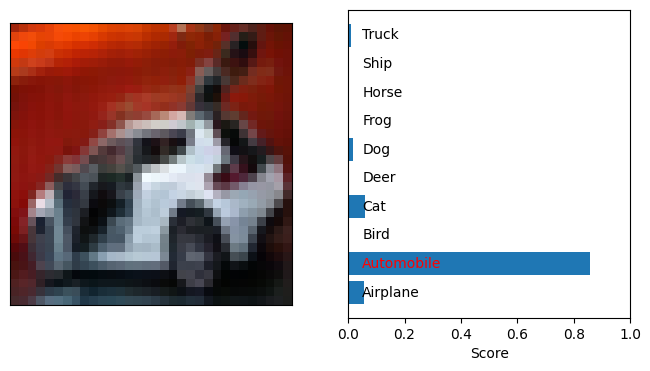

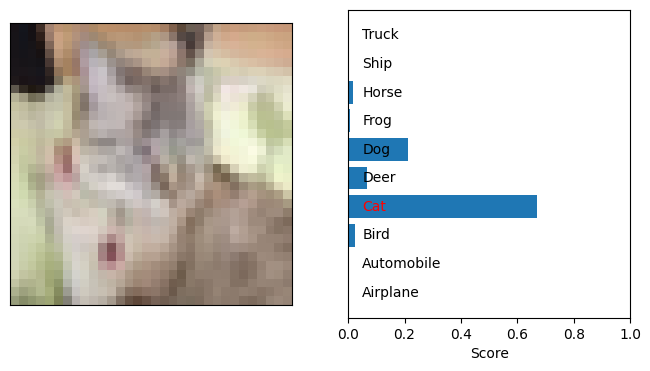

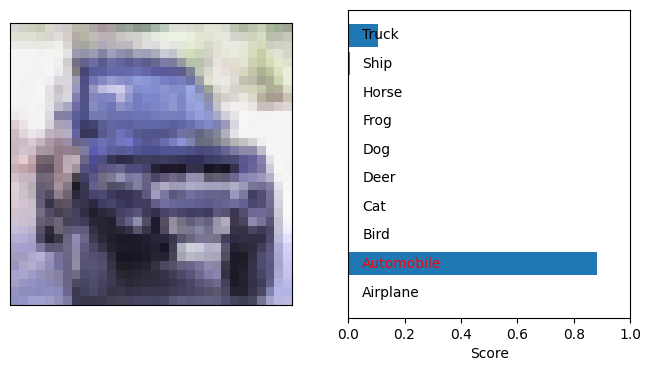

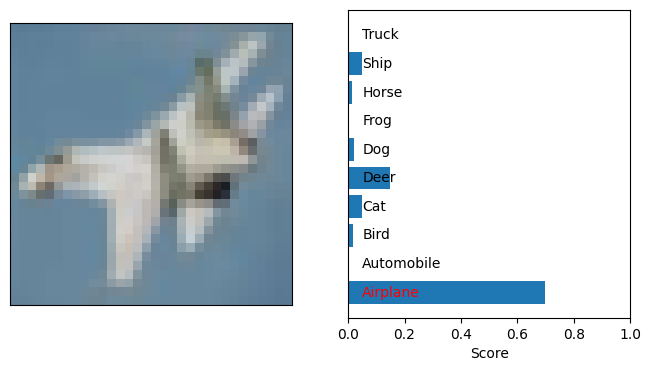

In [23]:
i1 = np.arange(8000)[m]

for i in i1[:10]:
    plot_prediction(
        x_test[i],
        y_test_onehot[i],
        y_predict[i]
    )
    plt.show()